# 7. 트랜스포머

## 트랜스포머 개념


### 위치 인코딩

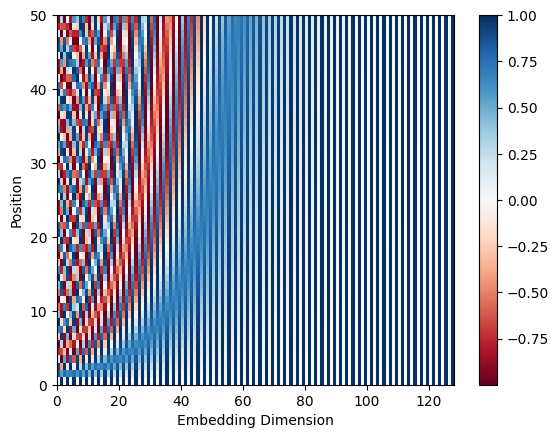

In [ ]:
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
  def __init__(self,d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)

    position = torch.arange(max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )

    pe = torch.zeros(max_len, 1, d_model)
    pe[:, 0, 0::2] = torch.sin(position * div_term)
    pe[:, 0, 1::2] = torch.cos(position * div_term)
    self.register_buffer("pe", pe)

  def forward(self, x):
    x = x + self.pe[: x.size(0)]
    return self.dropout(x)

encoding = PositionalEncoding(d_model=128, max_len=50)

plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap='RdBu')
plt.xlabel('Embedding Dimension')
plt.xlim((0, 128))
plt.ylabel('Position')
plt.colorbar()
plt.show()

## 모델 실습
- 파이토치에서 제공하는 트랜스포머 모델을 활용해 영어-독일어 번역 모델 구성
- 데이터세트: 자연어 처리를 위한 대규모 다국어 데이터세트 중 하나인 Multi30k
  - 영어-독일어 병렬 말뭉치(2개 국어 이상의 번역된 문서를 모은 말뭉치)
  - 약 30000개의 데이터 제공
  - 토치 데이터(torchdata), 토치 텍스트(torchtext) 라이브러리로 쉽게 다운로드

### 토치 데이터, 토치 텍스트 라이브러리 설치

In [ ]:
!pip install spacy

!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 90.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 89.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install --upgrade --force-reinstall \
    torch==2.0.1+cu118 \
    torchtext==0.15.2 \
    --extra-index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 571.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.3/63.3 MB 11.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 96.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install torchdata portalocker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

**<토치 데이터 라이브러리(`torchdata`)>**
- 대규모 데이터세트를 다루기 쉽게 데이터를 로드, 변환, 배치하는 간단하고 유연한 API 제공
- 데이터세트를 효율적으로 불러오고 배치할 수 있음.

**<토치 텍스트 라이브러리(`torchtext`)>**
- 파이토치를 위한 텍스트 처리 라이브러리
- 다양한 언어 모델링 작업에 대해 사전 처리
- 데이터세트 관리를 단순화하기 위한 다양한 도구, 기능 제공

**<포르타락커(`portalocker`) 라이브러리>**
- 파이썬에서 파일 락을 관리하기 위한 라이브러리
- 파일 락을 사용해 여러 프로세스 간에 동시에 파일을 수정하거나 읽는 것을 방지
- Multi30k 데이터세트를 다운로드하고 압축을 해제하는 과정에서 내부적으로 사용

### 데이터세트 다운로드, 전처리
- 토치 텍스트 라이브러리로 Multi30k 데이터세트 다운로드
- 독일어 말뭉치(de_core_news_sm)과 영어 말뭉치(en_core_web_sm)에 대해 각각 토크나이저, 어휘 사전 생성

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import torch
from torch import nn
from torchtext.datasets import Multi30k
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

# 독일어(de)와 영어(en) 텍스트를 처리하기 위해 토크나이저와 단어장(vocab) 준비

def generate_tokens(text_iter, language):
    # 언어별 인덱스 매핑: {'de': 0, 'en': 1}
    language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}

    # text_iter은 (src_sentence, tgt_sentence) 쌍을 반환하므로,
    # 원하는 언어의 문장을 토크나이저에 넣어 토큰을 생성
    for text in text_iter:
        yield token_transform[language](
            text[language_index[language]]
        )

# 소스(source)와 타겟(target) 언어 설정
SRC_LANGUAGE = 'de'
TGT_LANGUAGE = 'en'

# 특수 토큰 인덱스 정의
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ['<unk>', '<pad>', '<bos>', '<eos>']

# 언어별 토크나이저 설정 (spaCy 사용)
# get_tokenizer: 사용자가 지정한 토크나이저를 가져오는 유틸리티 함수
#     spaCy 라이브러리로 사전 학습된 모델을 가져옴 => token_transform 변수에 저장
token_transform = {
    SRC_LANGUAGE: get_tokenizer('spacy', language='de_core_news_sm'),
    TGT_LANGUAGE: get_tokenizer('spacy', language='en_core_web_sm')
}

print("Token Transform : ")
print(token_transform)

# vocab_transform: 토큰을 인덱스로 변환시키는 함수를 저장
vocab_transform = {}
# 각 언어별로 훈련 데이터셋을 순회하며 단어장 생성
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    # Multi30k 훈련 데이터 로드
    # Multi30k 데이터 세트를 활용해 (독일어, 영어)의 튜플 형식으로 데이터 로드
    train_iter = Multi30k(
        split='train',
        language_pair=(SRC_LANGUAGE, TGT_LANGUAGE)
    )
    # 토큰 제너레이터를 통해 iterator 생성 후 단어장 빌드
    # build_vocab_from_iterator: 생성된 토큰을 이용해 단어 집합 생성
    vocab_transform[language] = build_vocab_from_iterator(
        generate_tokens(train_iter, language),
        min_freq=1,                # 토큰화된 단어들의 최소 빈도수
        specials=special_symbols,  # 트랜스포머에 활용하는 특수 토큰 지정
        special_first=True         # 특수 토큰을 단어장 맨 앞에 배치
    )

# 단어장에 없는 토큰은 UNK_IDX로 매핑되도록 설정
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    # set_default_index: 메서드의 기본값을 설정. 어휘 사전에 없는 토큰인 <unk>의 인덱스 할당
    vocab_transform[language].set_default_index(UNK_IDX)

print("Vocab Transform : ")
print(vocab_transform)


Token Transform : 
{'de': functools.partial(<function _spacy_tokenize at 0x7b2543eee520>, spacy=<spacy.lang.de.German object at 0x7b252a538a10>), 'en': functools.partial(<function _spacy_tokenize at 0x7b2543eee520>, spacy=<spacy.lang.en.English object at 0x7b252a1be290>)}


SSLError: 
This exception is thrown by __iter__ of HTTPReaderIterDataPipe(skip_on_error=False, source_datapipe=OnDiskCacheHolderIterDataPipe, timeout=None)

#### 오류로 인해 직접 데이터세트 다운로드 후 전처리

In [ ]:
import os
DATA_ROOT = '/content/drive/MyDrive/Euron_DL/Week12'
os.makedirs(DATA_ROOT, exist_ok=True)

# GitHub 미러에서 SSL 검증 없이 다운로드
!wget --no-check-certificate -P {DATA_ROOT} \
    https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/training.tar.gz \
    https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/validation.tar.gz \
    https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/mmt16_task1_test.tar.gz

# 압축 풀기
!tar -xvzf {DATA_ROOT}/training.tar.gz   -C {DATA_ROOT}
!tar -xvzf {DATA_ROOT}/validation.tar.gz -C {DATA_ROOT}
!tar -xvzf {DATA_ROOT}/mmt16_task1_test.tar.gz -C {DATA_ROOT}

# 압축 해제된 파일 확인
!ls -lh {DATA_ROOT}

--2025-05-24 11:04:42--  https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/training.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1207136 (1.2M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/Euron_DL/Week12/training.tar.gz.1’

training.tar.gz.1   100%[===================>]   1.15M  --.-KB/s    in 0.05s   

2025-05-24 11:04:42 (23.8 MB/s) - ‘/content/drive/MyDrive/Euron_DL/Week12/training.tar.gz.1’ saved [1207136/1207136]

--2025-05-24 11:04:42--  https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/Multi30k/validation.tar.gz
Reusing existing connection to raw.githubusercontent.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 46329 (45K) [application/octet-stream]
Saving

In [ ]:
# 터미널(혹은 Colab 셀)에서
!ls -lh /content/drive/MyDrive/Euron_DL/Week12

total 5.6M
-rw------- 1 root root  66K May 24 11:04 mmt16_task1_test.tar.gz.1
-rw------- 1 root root  69K Oct 17  2016 test.de
-rw------- 1 root root  61K Oct 17  2016 test.en
-rw------- 1 root root  71K Feb 11  2017 test.fr
-rw------- 1 root root 2.1M Feb  2  2016 train.de
-rw------- 1 root root 1.8M Feb  2  2016 train.en
-rw------- 1 root root 1.2M May 24 11:04 training.tar.gz.1
-rw------- 1 root root  75K Feb  2  2016 val.de
-rw------- 1 root root  62K Feb  2  2016 val.en
-rw------- 1 root root  46K May 24 11:04 validation.tar.gz.1
-rw------- 1 root root 229K May 24 11:41 Week12_예습과제_방민지.ipynb


In [ ]:
# Python으로 읽어서 vocab 생성
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import gzip
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

# split→파일명 매핑
SPLIT_MAP = {
    'training': 'train',
    'validation': 'val',
    'mmt16_task1_test_2016': 'test'
}

def get_filepath(split: str, language: str) -> str:
    """
    split: 'training', 'validation', 'mmt16_task1_test_2016'
    실제 파일은 train.de, valid.de, test.de 등이므로 맵핑 처리
    """
    base = SPLIT_MAP.get(split, split)
    gz_path = os.path.join(DATA_ROOT, f"{base}.{language}.gz")
    txt_path = os.path.join(DATA_ROOT, f"{base}.{language}")
    if os.path.exists(gz_path):
        return gz_path
    elif os.path.exists(txt_path):
        return txt_path
    else:
        raise FileNotFoundError(f"No file for split={split}, lang={language}")

def read_corpus(split: str, language: str):
    path = get_filepath(split, language)
    if path.endswith('.gz'):
        with gzip.open(path, 'rt', encoding='utf-8') as f:
            for line in f:
                yield line.strip()
    else:
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                yield line.strip()

In [ ]:
# 토크나이저 & 특수토큰 세팅
SRC_LANGUAGE = 'de'
TGT_LANGUAGE = 'en'
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ['<unk>', '<pad>', '<bos>', '<eos>']

token_transform = {
    SRC_LANGUAGE: get_tokenizer('spacy', language='de_core_news_sm'),
    TGT_LANGUAGE: get_tokenizer('spacy', language='en_core_web_sm')
}


# 토큰 생성기
def generate_tokens(text_iter, language):
    language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}
    for text_pair in text_iter:
        # text_pair 는 (src_sentence, tgt_sentence)
        yield token_transform[language](
            text_pair[language_index[language]]
        )

print("Token Transform : ")
print(token_transform)


Token Transform : 
{'de': functools.partial(<function _spacy_tokenize at 0x7b2543eee520>, spacy=<spacy.lang.de.German object at 0x7b24f09c6850>), 'en': functools.partial(<function _spacy_tokenize at 0x7b2543eee520>, spacy=<spacy.lang.en.English object at 0x7b24d3211d10>)}


In [ ]:
def yield_tokens(split_names, language):
    language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}
    for split in split_names:
        # split마다 fresh iterator 생성
        pairs = zip(
            read_corpus(split, SRC_LANGUAGE),
            read_corpus(split, TGT_LANGUAGE)
        )
        for src_tgt in pairs:
            yield token_transform[language](src_tgt[language_index[language]])

# vocab_transform 생성
vocab_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    tokens = yield_tokens(['training', 'validation'], language)
    vocab = build_vocab_from_iterator(
        tokens,
        min_freq=1,
        specials=special_symbols,
        special_first=True
    )
    vocab.set_default_index(UNK_IDX)
    vocab_transform[language] = vocab


print("Vocab Transform : ")
print(vocab_transform)

Vocab Transform : 
{'de': Vocab(), 'en': Vocab()}


### 트랜스포머 모델 구성

In [ ]:
import math
import torch
from torch import nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        # 드롭아웃 확률 설정
        self.dropout = nn.Dropout(p=dropout)

        # 위치 인코딩을 위한 위치 번호 벡터: [0, 1, ..., max_len-1]
        position = torch.arange(max_len).unsqueeze(1)  # (max_len, 1)
        # 주기 파라미터 계산: 각 짝수 차원마다 다른 주기 사용
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )  # (d_model/2,)

        # 최대 길이만큼 위치 인코딩 행렬 초기화
        pe = torch.zeros(max_len, 1, d_model)  # (max_len, 1, d_model)
        # 짝수 인덱스 차원에는 sin, 홀수 인덱스 차원에는 cos 적용
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        # buffer로 등록하여 모델 파라미터로 학습되지 않도록 함
        self.register_buffer("pe", pe)

    def forward(self, x):
        # 입력 시퀀스 길이만큼 위치 인코딩 더하기
        x = x + self.pe[: x.size(0)]
        # 드롭아웃 적용 후 반환
        return self.dropout(x)

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        # 단어 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, emb_size)
        # 임베딩 차원 저장
        self.emb_size = emb_size

    def forward(self, tokens):
        # 임베딩 스케일링: sqrt(emb_size) 곱해 안정화
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)

# TokenEmbedding 클래스
# 소스 데이터와 입력 데이터를 입력 임베딩으로 변환 -> src_tok_emb, tgt_tok_emb 생성
# 소스와 타깃 데이터의 어휘 사전 크기를 입력 -> 트랜스포머 임베딩 크기로 변환
class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers,
        num_decoder_layers,
        emb_size,
        max_len,
        nhead,
        src_vocab_size,
        tgt_vocab_size,
        dim_feedforward,
        dropout=0.1,
    ):
        super().__init__()
        # 소스 및 타겟 토큰 임베딩
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        # 위치 인코딩 모듈
        self.positional_encoding = PositionalEncoding(
            d_model=emb_size, max_len=max_len, dropout=dropout
        )
        # Transformer 블록 (인코더+디코더)
        self.transformer = nn.Transformer(  # 파이토치에서 제공되는 Transformer 클래스 적용
            # 인코더와 디코더는 encoder_layers 변수 값으로 구성
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        # 최종 출력용 선형 레이어 (어휘 크기로 매핑)
        # 마지막 트랜스포머 디코더 블록에서 산출되는 벡터를 선형 변환 -> 어휘 사전에 대한 로짓(logit) 생성
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(
        self,
        src,
        trg,
        src_mask,
        tgt_mask,
        src_padding_mask,
        tgt_padding_mask,
        memory_key_padding_mask,
    ):
        # 소스 입력 임베딩 + 위치 인코딩
        src_emb = self.positional_encoding(self.src_tok_emb(src))  # (S, N, E)
        # 타겟 입력 임베딩 + 위치 인코딩
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))  # (T, N, E)
        # Transformer 인코더-디코더 통과
        outs = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )  # (T, N, E)
        # 생성 레이어로 어휘 차원으로 변환
        return self.generator(outs)

    def encode(self, src, src_mask):
        # 인코더만 실행하는 헬퍼 메서드
        return self.transformer.encoder(
            self.positional_encoding(self.src_tok_emb(src)), src_mask
        )

    def decode(self, tgt, memory, tgt_mask):
        # 디코더만 실행하는 헬퍼 메서드
        return self.transformer.decoder(
            self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask
        )


### 트랜스포머 클래스
- 파이토치에서 제공하는 트랜스포머 클래스를 활용하면 트랜스포머 구조의 모델을 쉽게 구현할 수 있음

**<트랜스포머 클래스>**
```
transformer = torch.nn.Transformer(
  d_model=512,
  nhead=8,
  num_encoder_layers=6,
  num_decoder_layers=6,
  dim_feedforward=2048,
  dropout=0.1,
  activation=torch.nn.functional.relu,
  layer_norm_eps=1e-05,
)
```
- d_model(임베딩 차원): 트랜스포머 모델의 입출력 차원의 크기를 정의
- head(헤드): 멀티 헤드 어텐션의 헤드 개수를 정의
  - 헤드 개수가 많을수록 병렬 처리 능력이 증가. 하지만 모델 매개변수의 수도 증가
- num_encoder_layers(인코더 계층 수), num_decoder_layers(디코더 계층 수): 인코더와 디코더의 계층 수
  - 모델의 복잡도와 성능에 영향을 미침
  - 계층 개수가 많을수록 더 복잡한 문제를 해결
  - 너무 많을 경우 과적합 위험
- dim_feedforward(순방향 신경망 크기): 순방향 신경망의 은닉층 크기를 정의
  - 순방향 신경망 계층은 트랜스포머 계층의 각 입력 위치에 독립적으로 적용
  - 인코더/디코더 계층과 마찬가지로 모델의 복잡도, 성능에 영향을 미침
- dropout(드롭아웃): 인코더, 디코더 계층에 적용되는 드롭아웃 비율을 적용
- activivation(활성화 함수): 순방향 신경망에 적용되는 활성화 함수
  - 활성화 함수는 파이토치 함수 형태로 입력
- layer_norm_eps(계층 정규화 입실론): 계층 장규화를 수행할 때 분모에 더해지는 입실론 값을 정의

**<트랜스포머 순방향 메서드>**
- 인스턴스의 설정과 입력 시퀀스를 통해 타깃 시퀀스의 임베딩 텐서를 반환
- [타깃 시퀀스 길이, 배치 크기, 임베딩 차원] 반환
```
output = transformer.forward(
  src,
  tgt,
  src_mask=None,
  tgt_mask=None,
  memory_mask=None,
  src_key_padding_mask=None,
  tgt_key_padding_mask=None,
  memory_key_padding_mask=None,
```
- src(소스),tgt(타깃): 인코더와 디코더에 대한 시퀀스
  - [소스(타깃) 시퀀스 길이, 배치 크기, 임베딩 차원] 형태의 데이터를 입력
- src_mask(소스 마스크), tgt_mask(타깃 마스크): 소스와 타깃 시퀀스의 마스크
  - [소스(타킷) 시퀀스 길이, 시퀀스 길이] 형태의 데이터 입력
  - 마스크 값이 0: 해당 위치에서는 모든 입력 단어가 동일한 가중치를 갖고 어텐션 수행
  - 마스크 값이 1: 모든 입력 단어의 가중치가 0으로 설정되어 어텐션 연산이 수행되지 않음
  - 마스크 값이 -inf: 해당 위치에서는 어텐션 연산 결과에 0으로 가중치가 부여돼 마스킹된 위치의 정보를 모델이 무시하게 만듬
  - 마스크 값이 +inf: 모든 입력 단어에 무한대의 가중치가 부여돼 어텐션 연산 결과가 해단 위치에 대한 정보만으로 구성

    => 일반적으로 적용하지 않으며 어떤 특정 단어나 위치에 대해 모델이 특별한 관심을 가지도록 할 때만 사용
- memory_mask(메모리 마스크): 인코더의 출력 마스크
  - [타깃 시퀀스 길이, 소스 시퀀스 길이] 형태
  - 메모리 마스크 값이 0인 위치에서는 어텐션 연산이 수행되지 않음
- src_key_padding_mask(소스 키 패딩 마스크), tgt_key_padding_mask(타깃 키 패딩 마스크), memory_key_padding_mask(메모리 키 패딩 마스크): 소스, 타깃, 메모리 시퀀스에 대한 패딩 마스크
  - [배치 크기, 소스(타깃) 시퀀스 길이] 형태 입력
  - 메모리 키 패딩 마스크: 소스 키 패딩 마스크와 동일한 형태의 데이터를 입력 받음
  - 키 패딩 마스크: 입력 시퀀스에서 패딩 토큰이 위치한 부분을 가리키는 이진 마스크. 패딩 토큰이 실제 의미를 가지지 않는 것으로 간주되어 해당 위치의 어텐션 연산 결과에 대한 가중치를 0으로 만듬



### 트랜스포머 모델 선언 방식, 구조

In [ ]:
from torch import optim

# 학습에 사용할 배치 크기와 디바이스 설정
BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Seq2SeqTransformer 모델 초기화 및 디바이스로 이동
model = Seq2SeqTransformer(
    num_encoder_layers=3,    # 인코더 레이어 수
    num_decoder_layers=3,    # 디코더 레이어 수
    emb_size=512,            # 임베딩 및 모델 차원
    max_len=512,             # 최대 시퀀스 길이
    nhead=8,                 # 멀티헤드 어텐션 헤드 수
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),  # 소스 언어 어휘 크기
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),  # 타겟 언어 어휘 크기
    dim_feedforward=512,     # 피드포워드 네트워크 차원
).to(DEVICE)

# 손실 함수: 패딩 토큰 인덱스 무시
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
# 옵티마이저: Adam
optimizer = optim.Adam(model.parameters())

# 모델 구조 출력 (named_children를 이용한 계층별 모듈 탐색)
for main_name, main_module in model.named_children():
    print(main_name)  # 최상위 모듈 이름 출력

    for sub_name, sub_module in main_module.named_children():
        print(f"L {sub_name}")  # 1단계 하위 모듈
        for ssub_name, ssub_module in sub_module.named_children():
            print(f"| L {ssub_name}")  # 2단계 하위 모듈
            for sssub_name, sssub_module in ssub_module.named_children():
                print(f"| | L {sssub_name}")  # 3단계 하위 모듈


src_tok_emb
L embedding
tgt_tok_emb
L embedding
positional_encoding
L dropout
transformer
L encoder
| L layers
| | L 0
| | L 1
| | L 2
| L norm
L decoder
| L layers
| | L 0
| | L 1
| | L 2
| L norm
generator


**<Seq2SeqTransformer 클래스>**
- 입력 임베딩(src_tok_emb, tgt_tok_emb), 위치 인코딩(positional_encoding), 트랜스포머 블록(transformer),로짓 생성(generator)으로 구성

**<구조>**
- 인코더, 디코더가 각각 세 개(0, 1, 2)의 계층으로 구성
- 손실 함수: 교차 엔트로피
- 무시되는 색인(ignore_index) 값을 패딩 토큰(PAD_IDX)을 할당 => 모델이 학습하는 동안 무시해야 할 클래스 레이블을 지정
  - 패딩 토큰: 모델 학습에 사용되지 않으므로 해당 토큰에 대한 레이블을 무시하고 모델이 해당 클래스를 학습하지 않게 함

### 배치 데이터 생성

In [ ]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch

# 여러 개의 전처리 함수를 인자로 받아 이를 차례로 적용하는 함수를 반환
def sequential_transforms(*transforms):
    def func(text):
        for transform in transforms:
            text = transform(text)
        return text
    return func

# BOS/EOS 토큰 추가
def input_transform(token_ids):
    return torch.cat([
        torch.tensor([BOS_IDX]),     # 문장 시작 토큰
        torch.tensor(token_ids),     # 본래 토큰 ID들
        torch.tensor([EOS_IDX])      # 문장 종료 토큰
    ])

# 집합 함수
# 배치 단위로 데이터 처리
def collator(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        # 문자열 끝의 \n을 제거 -> text_transform 변수에 저장된 sequential_transforms 함수 적용
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))
    # 패딩 시퀀스 함수를 사용해 소스와 타깃 시퀀스를 패딩
    # 동일한 길이를 가지도록 시퀀스의 뒤쪽에 PAD_IDX(1)로 채워진 패딩 토큰 추가
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch # [소스(타깃) 시퀀스 길이, 배치 크기]

# 텍스트 → 토큰화 → 인덱스 → BOS/EOS 적용
text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language],    # 문장 토큰화
        vocab_transform[language],    # 각 토큰을 인덱스화
        input_transform               # 인덱스화된 토큰에 문장의 시작과 끝을 알리는 특수 토큰 할당
    )

# 로컬 validation 데이터를 한 쌍씩 읽어 리스트로 변환
#    zip 객체는 __len__이 없어 DataLoader가 오류를 내므로, 리스트로 감쌈
valid_pairs = list(zip(
    read_corpus('validation', SRC_LANGUAGE),
    read_corpus('validation', TGT_LANGUAGE)
))

# DataLoader 생성
# (패딩이 적용된 소스, 패딩이 적용된 타깃) 튜플을 반환
dataloader = DataLoader(
    valid_pairs,           # 리스트화된 (src, tgt) 쌍
    batch_size=BATCH_SIZE,
    collate_fn=collator
)

# 첫 배치 가져오기
source_tensor, target_tensor = next(iter(dataloader))

# 출력
print("(source, target) raw example:")
print(valid_pairs[0])   # 리스트이므로 인덱싱 가능

print("source_batch shape:", source_tensor.shape)
print(source_tensor)

print("target_batch shape:", target_tensor.shape)
print(target_tensor)

(source, target) raw example:
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')
source_batch shape: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  14,    5,    5,  ...,    5,   21,    5],
        [  38,   12,   35,  ...,   12, 1610,   68],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])
target_batch shape: torch.Size([30, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [   6,    6,    6,  ...,  247,   19,    6],
        [  39,   12,   35,  ...,   12, 2943,   61],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


### 어텐션 마스크 생성

In [ ]:
import torch

# 마스크를 생성하는 함수
# s x s 크기의 사각 마스크를 만들어, 디코더가 미래 토큰을 보지 못하도록 차단
def generate_square_subsequent_mask(s):
    # 상삼각 행렬(upper triangular)을 생성하고, transpose하여 하삼각(과 대각선) 부분이 True가 되게 함
    # torch.ones를 사용해 1로 채워진 행렬을 만든 후 torch.triu를 적용하여 상삼각행렬을 생성 -> transpose를 사용하여 행렬을 전치
    mask = (torch.triu(torch.ones((s, s), device=DEVICE)) == 1).transpose(0, 1)
    # mask==0 영역은 -inf, mask==1 영역은 0.0 값으로 채워서 소프트맥스 시 확률이 0이 되도록 설정
    mask = (
        mask.float()
            .masked_fill(mask == 0, float('-inf'))
            .masked_fill(mask == 1, float(0.0))
    )
    return mask

# 패딩 마스크를 생성하는 함수
# 시퀀스를 입력받아 길이를 계산 -> 마스크 생성 함수로 타깃 시퀀스의 마스크 생성
def create_mask(src, tgt):
    src_seq_len = src.shape[0]  # 소스 시퀀스 길이 (time dimension)
    tgt_seq_len = tgt.shape[0]  # 타겟 시퀀스 길이

    # 디코더용 인과적(causal) 마스크: 미래 토큰 정보 차단
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    # 인코더용 마스크: 패딩만 처리하므로 전부 False (정보 차단 없음)
    # 소스 시퀀스 길이의 크기로 채워진 행렬을 생성
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE, dtype=torch.bool)

    # 패딩 토큰 위치를 True로 표시 (batch dimension 기준)
    # (src == PAD_IDX) -> (time_steps, batch) 형태 -> transpose -> (batch, time_steps)
    src_padding_mask = (src == PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)

    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

# 토큰 순서를 한 칸 shift => 이전 토큰들이 주어졌을 때 다음 토큰을 예측
target_input = target_tensor[:-1, :]
target_out   = target_tensor[1:, :]

# 실제 마스크 생성 호출
# 소스 시퀀스 입력값과 타깃 시퀀스 입력값을 전달 -> 4개의 텐서 생성
source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor,
    target_input
)
'''
- source_mask: 셀프 어텐션 과정에서 참조되는 소스 데이터의 시퀀스 범위
   - False인 위치 => 셀프 어텐션에 참조되는 토큰
   - True인 위치 => 어텐션에서 제외되는 토큰

- target_mask: [쿼리 시퀀스 길이, 키 시퀀스 길이]의 형태로 구성
   - i번째 쿼리 벡터는 i+1 이상의 키 벡터에 대해 어텐션 연산을 수행할 수 없게 됨
   - 모델이 현재 예측하고자 하는 위치 이전의 토큰들만 참고하게 제한 => 모델이 미래 시점의 정보 X => 현재 시점에 영향 X

- source_padding_mask, target_padding_mask: 소스(타깃) 배치 데이터에서 텍스트 토큰이 존재하는지 여부를 나타내는 값
   - False인 경우 => 해당 토큰 인덱스가 존재
   - True인 경우 => 해당 토큰 인덱스가 패딩 토큰으로 채워져 있음
'''

# 생성된 마스크 및 패딩 마스크 형태와 값을 확인
print("source_mask:", source_mask.shape)
print(source_mask)

print("target_mask:", target_mask.shape)
print(target_mask)

print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)

print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)


source_mask: torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:0')
target_mask: torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf,

### 모델 학습, 평가

In [ ]:
# 모델 학습 및 평가를 위한 함수
# 소스와 타깃 데이터를 입력받아 collator로 문장들을 토큰화하고 인덱스로 변환
def run(model, optimizer, criterion, split):
    # 모델 모드 설정: train 모드일 때만 파라미터 업데이트 허용
    if split == "training":
        model.train()
    else:
        model.eval()

    # 로컬 파일을 직접 읽어서 (src, tgt) 쌍 리스트 생성
    #    'training'→train.de/ train.en, 'validation'→val.de/ val.en 사용
    data_iter = list(zip(
        read_corpus(split, SRC_LANGUAGE),
        read_corpus(split, TGT_LANGUAGE)
    ))

    # DataLoader 준비 (collator로 패딩)
    dataloader = DataLoader(
        data_iter,
        batch_size=BATCH_SIZE,
        collate_fn=collator
    )

    total_loss = 0.0
    # 배치 단위 반복
    for source_batch, target_batch in dataloader:
        # GPU/CPU로 배치 이동
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        # 디코더 입력/출력 분리 (right-shift)
        # 입력은 처음부터 끝-1, 출력은 두번째부터 끝까지
        target_input  = target_batch[:-1, :]
        target_output = target_batch[1:, :]

        # create_mask: 입력 패딩 마스크, 어텐션 마스크 생성
        # 결괏값: 타깃 시퀀스의 i번째까지 토큰이 주어졌을 때 i+1번째 토큰을 예측하는 데 활용
        src_mask, tgt_mask, src_pad_mask, tgt_pad_mask = create_mask(
            source_batch, target_input
        )

        # 순전파: 모델에 입력하고 로짓(logits) 반환
        logits = model(
            src=source_batch,
            trg=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_pad_mask,
            tgt_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask
        )

        # 손실 계산
        # 로짓과 정답을 reshape해 (토큰수×배치, vocab_size) vs (토큰수×배치) 형태로 맞춤
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            target_output.reshape(-1)
        )

        # train split에서만 역전파 및 파라미터 업데이트
        if split == "training":
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # 배치 손실 누적
        total_loss += loss.item()

    # 평균 손실 반환
    return total_loss / len(list(dataloader))


# 실제 학습/평가 루프: 5 epochs 실행
for epoch in range(1, 6):
    train_loss = run(model, optimizer, criterion, "training")
    val_loss   = run(model, optimizer, criterion, "validation")
    print(f"Epoch {epoch}: Train Loss = {train_loss:.3f}, Val Loss = {val_loss:.3f}")


Epoch 1: Train Loss = 5.403, Val Loss = 5.007
Epoch 2: Train Loss = 4.952, Val Loss = 4.868
Epoch 3: Train Loss = 4.734, Val Loss = 5.008
Epoch 4: Train Loss = 4.634, Val Loss = 4.702
Epoch 5: Train Loss = 4.742, Val Loss = 5.226


### 트랜스포머 모델 번역 결과

In [ ]:
# 그리디 디코딩 함수 (Greedy Decoding)
# - 주어진 source 텐서로부터 한 토큰씩 예측하며, 가장 높은 확률의 단어를 선택
# - max_len 토큰까지 생성하되, EOS 토큰이 나오면 중단
# - 현재 시점에서 가장 확률이 높은 단어를 선택하여 디코딩
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    # 디바이스로 이동
    source_tensor = source_tensor.to(DEVICE)
    source_mask   = source_mask.to(DEVICE)

    # 모델 추론 방식: 디코더에 참조되느 마지막 인코더 트랜스포머 블록의 벡터(memory), 타깃데이터의 입력 텐서(ys), 타깃 마스크(target_mask)사용
    # 소스 문장을 토큰 인덱스로 표현한 source_tensor 생성
    # source_mask는 소스문장에서 모든 토큰이 어텐션 될 수 있게 0으로 설정
    # .encode: source_tensor, source_mask 입력으로 넣어 소스 문장에 대한 인코딩 수행 -> 마지막 인코더 트랜스포머 블록의 벡터 추출
    memory = model.encode(source_tensor, source_mask)


    # 디코더 입력 초기화: 시작 토큰(BOS)로 시작
    ys = torch.ones(1, 1).fill_(start_symbol).long().to(DEVICE)

    # 최대 길이만큼 반복
    for i in range(max_len - 1):
        # ensure memory on correct device
        memory = memory.to(DEVICE)
        # 디코더용 subsequent mask 생성 (미래 토큰 정보 차단)
        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask = target_mask.bool().to(DEVICE)

        # 디코더 실행: 현재까지 생성된 ys + memory + mask -> decoder outputs
        # out: [토큰 개수, 배치 크기, 확률] 형태
        out = model.decode(ys, memory, target_mask)
        # (T, N, E) -> (N, T, E) 형태로 변환
        out = out.transpose(0, 1) # [배치 크기, 토큰 개수, 확률] 형태로 변환

        # 마지막 시점의 로짓을 generator(선형층)에 전달하여 어휘 차원 점수 획득
        prob = model.generator(out[:, -1])  # 슬라이싱 -> [배치 크기, 확률] 형태
        # 가장 높은 점수를 갖는 단어 인덱스 선택
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        # 선택된 단어를 ys 뒤에 추가
        ys = torch.cat([
            ys,
            torch.tensor([[next_word]], device=DEVICE, dtype=ys.dtype)
        ], dim=0)

        # EOS 토큰이 생성되면 중단
        if next_word == EOS_IDX:
            break

    return ys  # 생성된 토큰 시퀀스 반환 (including BOS and EOS)

# 번역 함수 (Translate)
# - 입력 문장을 텍스트 -> 토큰 -> 인덱스 -> 텐서로 변환
# - greedy_decode로 디코딩 후, 인덱스를 다시 토큰(단어)로 변환
def translate(model, source_sentence):
    # 평가 모드 설정
    model.eval()

    # source 문장 전처리: 토큰화 -> 인덱스 변환 -> (time, 1) 형태 텐서
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens    = source_tensor.size(0)

    # 인코더 마스크: 패딩 없이 모두 False
    src_mask = torch.zeros(num_tokens, num_tokens, dtype=torch.bool).to(DEVICE)

    # greedy 디코딩 수행
    # max_len 이전이거나 EOD_IDX를 예측할 때까지 반복
    # 예측된 토큰 시퀀스를 반환
    tgt_tokens = greedy_decode(
        model,
        source_tensor,
        src_mask,
        # num_tokens: 소스 문장의 토큰 개수
        # 일반적으로 생성된 문장의 길이가 소스 문장 길이보다 약간 더 길어지는 경우가 많기 때문에 5를 더함
        max_len=start_symbol if False else num_tokens + 5,
        start_symbol=BOS_IDX
    ).flatten()

    # 예측된 토큰 인덱스를 lookup_tokens를 통해 실제 단어로 변환
    # <bos>, <eos> 토큰을 슬라이싱으로 제거
    generated_tokens = tgt_tokens.cpu().tolist()
    output_tokens    = vocab_transform[TGT_LANGUAGE].lookup_tokens(generated_tokens)[:-1]

    # 공백으로 결합하여 최종 번역문 리턴
    return " ".join(output_tokens)

# 예시 실행
# - OOV(Out-of-Vocabulary) 예시
output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu.")
# - 일반 문장 예시
output     = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")

print(output_oov)
print(output)


<bos> A man a .
<bos> A man a .


# GPT

## 모델 실습
- 허깅 페이스 트랜스포머스 라이브러리의 GPT-2 모델로 문장 생성

### GPT-2 모델 구조 확인

In [1]:
from transformers import GPT2LMHeadModel

# from_pretained 메서드로 사전 학습된 GPT-2 로드
# pretrained_model_name_or_path 매개변수: 불러오려는 사전 학습된 모델
model = GPT2LMHeadModel.from_pretrained(pretrained_model_name_or_path="gpt2")

for main_name, main_module in model.named_children():
  print(main_name)
  for sub_name, sub_module in main_module.named_children():
    print("L ", sub_name)
    for ssub_name, ssub_module in sub_module.named_children():
      print("| L ", ssub_name)
      for sssub_name, sssub_module in ssub_module.named_children():
        print("| | L ", sssub_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


transformer
L  wte
L  wpe
L  drop
L  h
| L  0
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  1
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  2
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  3
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  4
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  5
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  6
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  7
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  8
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  9
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  10
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
| L  11
| | L  ln_1
| | L  attn
| | L  ln_2
| | L  mlp
L  ln_f
lm_head


**<모델 구조>**
- 48개의 디코더 계층을 사용하는 모델이 아니하, 12개의 디코더 계층을 사용하는 간소화 모델인 gpt2 사용
  - 48개의 디코더 계층을 사용하는 모델 => gpt2-xl
- wte: 단어 토큰 임베딩
- wpe: 단어 위치 임베딩
- drop: 드롭아웃
- h: 트랜스포머 디코더 계층
- lm_head: 선형 임베딩 및 언어 모델

### GPT-2를 이용한 문장 생성
- 트랜스포머스 라이브러리의 파이프라인 함수

  : 문장 분류, 문장 생성, 토큰 분류 등 다양한 작업에 대한 전처리, 모델 아키텍처, 후처리를 처리

In [2]:
from transformers import pipeline
'''
파이프라인 클래스
  - 입력된 작업(task)에 모델(model)로 적합한 파이프라인을 구축
  - 작업 매개변수: 수행하려는 작업
  - 반환: 설정한 작업을 수행하는 파이프라인 클래스의 인스턴스

'''
generator = pipeline(task="text-generation", model="gpt2")  # 매개변수: task, model
# text-generation: 텍스트 생성 작업 -> TextGenerationPipeline 클래스 생성

outputs = generator(
    text_inputs="Machine learning is ", # 생성하려는 문장의 입력 문맥
    max_length=20,  # 생성될 문장의 최대 토큰 수를 제한
    num_return_sequences=3, # 생성할 텍스트 시퀀스의 수
    pad_token_id=generator.tokenizer.eos_token_id)  # 모델의 자유 생성 여부. 모델이 입력된 문장의 문맥을 기반으로 자유롭게 다음 단어/문장 생성

print(outputs)

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


[{'generated_text': 'Machine learning is 그이 안가귭. This'}, {'generated_text': 'Machine learning is \xa0really\xa0hard. Here, the task is to get at the bottom of'}, {'generated_text': 'Machine learning is iced on the spot and I am amazed at how well it can be applied in'}]


### 다운스트림 작업에 활용
- GPT-2 모델은 선형 임베딩 층을 이용해 텍스트 분류 등 다양한 다운스트림 작업에 활용
- CoLA(The Corpus of Limguistic Acceptability) 데이터세트를 이용해 모델을 학습

#### CoLA 데이터세트 로드
- 문법적으로 올바른 문장과 올바르지 않은 문장을 포함하는 영어 문장 말뭉치 데이터세트
- train, dev, test로 구성
  - train: 모델 학습에 사용
  - dev: 모델 검증에 사용
  - test: 모델 성능 평가에 사용

In [ ]:
!pip install torchtext

In [3]:
import torch
from torchtext.datasets import CoLA
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

# 데이터 배치 하나를 처리하는 함수 정의
# 배치를 토크나이저로 토큰화, 패딩, 절사, 반환 형식 설정 작업 수행
def collator(batch, tokenizer, device):
  source, labels, texts = zip(*batch) # 배치 데이터를 튜플 형식으로 분리 (source는 사용하지 않음)
  tokenized = tokenizer(
      texts,  # 문장 리스트
      padding="longest",  # 가장 긴 문장에 맞춰 padding 적용
      truncation=True,  # 최대 길이를 초과하는 경우 해당 시퀀스를 자름
      return_tensors="pt"  # PyTorch 텐서로 결과 반환
  )
  input_ids = tokenized["input_ids"].to(device) # input_ids 텐서를 GPU 또는 CPU로 이동
  attention_mask = tokenized["attention_mask"].to(device)  # attention mask도 동일하게 처리
  labels = torch.tensor(labels, dtype=torch.long).to(device)  # 라벨을 LongTensor로 변환 후 디바이스로 이동
  return input_ids, attention_mask, labels # 토큰 ID, 어텐션 마스크 반환
  #   토큰 ID: 토크나이저가 각 토큰에 대해 부여한 숫자 ID를 담고 있음
  #   어텐션 마스크: 입력 문장의 실제 단어에 대응하는 부분은 1, 패딩에 대응하는 부분은 0으로 채움
  # GPT 모델은 어텐션 마스크를 이용해 입력 문장에서 패딩 부분을 무시하고 실제 단어에 대해 처리

# CoLA 데이터셋 로드 (train, dev, test로 분할)
train_data = list(CoLA(split="train"))
valid_data = list(CoLA(split="dev"))
test_data = list(CoLA(split="test"))

# GPT-2용 tokenizer 불러오기
tokenizer = AutoTokenizer.from_pretrained("gpt2")
# GPT-2는 사전 학습 시 패딩 기법을 사용 X => 패딩 토큰이 포함되어있지 않음 => 문장의 끝을 의미하는 eos 토큰으로 대체
tokenizer.pad_token = tokenizer.eos_token

# 학습 관련 설정
epochs = 3
batch_size = 16
device = "cuda" if torch.cuda.is_available() else "cpu"  # GPU 사용 가능하면 cuda, 아니면 cpu

# 학습 데이터 로더 생성
train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device),  # 배치마다 collator 적용
    shuffle=True, # 학습 시 셔플 적용
)

# 검증 데이터 로더 생성
valid_dataloader = DataLoader(
    valid_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device)
)

# 테스트 데이터 로더 생성
test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device)
)

# 데이터셋 크기 출력
print("Train Dataset Length: ", len(train_data))
print("Valid Dataset Length: ", len(valid_data))
print("Test Dataset Length: ", len(test_data))


OSError: /usr/local/lib/python3.11/dist-packages/torchtext/lib/libtorchtext.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs

##### 오류로 인한 huggingface 데이터세트 사용

In [2]:
!pip install -U datasets fsspec huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.3/509.3 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 90.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.31.2
    Uninstalling huggingface-hub-0.31.2:
      Successfully uninstalled huggingface-hub-0.31.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency c

In [1]:
from datasets import load_dataset

dataset = load_dataset("glue", "cola")  # 자동으로 로컬에 캐시됨
train_data = dataset["train"]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/251k [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/37.6k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/37.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8551 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1063 [00:00<?, ? examples/s]

In [2]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 8551
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1043
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1063
    })
})


In [10]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

# Hugging Face datasets 로드
cola = load_dataset("glue", "cola")
train_data = cola["train"]
valid_data = cola["validation"]
test_data = cola["validation"]

# GPT-2 tokenizer 설정
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Collator 함수 정의
def collator(batch, tokenizer, device):
    texts = [item["sentence"] for item in batch]
    labels = [item["label"] for item in batch]

    # 라벨 값이 이상한 게 있는지 출력 (디버깅용)
    print("Label values in batch:", labels)
    assert all(l in [0, 1] for l in labels), "라벨에 0, 1 이외의 값이 있음!"

    tokenized = tokenizer(
        texts,
        padding="longest",
        truncation=True,
        return_tensors="pt"
    )
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)
    labels = torch.tensor(labels, dtype=torch.long).to(device)
    return input_ids, attention_mask, labels


# DataLoader 생성
batch_size = 16
device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device),
    shuffle=True,
)
valid_dataloader = DataLoader(
    valid_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device)
)
test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device)
)

# 길이 출력
print("Train Dataset Length: ", len(train_data))
print("Valid Dataset Length: ", len(valid_data))
print("Test Dataset Length: ", len(test_data))


Train Dataset Length:  8551
Valid Dataset Length:  1043
Test Dataset Length:  1043


#### 모델 설정

In [4]:
from torch import optim
from transformers import GPT2ForSequenceClassification
# GPT-2 문장 분류 모델 클래스(GPT2ForSequenceClassification)
#   - GPT-2 모델을 기반으로 하는 시퀀스 분류 모델
#   - 기본 GPT-2 모델과 유사하게 작동
#   - 최종 출력 계층이 분류를 위해 미세 조정

model = GPT2ForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="gpt2",
    num_labels=2  # 올바른 문장/올바르지 않은 문장이 태깅 => 분류 레이블 수:2
).to(device)

model.config.pad_token_id = model.config.eos_token_id
# 패딩 토큰을 eos 토큰으로 대체 => 문장 분류 모델에서 필요로 하는 고정된 길이의 입력 제공

optimizer = optim.Adam(model.parameters(), lr=1e-5)

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### 모델 학습, 검증

In [5]:
import numpy as np
from torch import nn

epochs = 3

# 예측값과 실제 정답 레이블을 비교하여 정확도(accuracy)를 계산하는 함수
def calc_accuracy(preds, labels):
  pred_flat = np.argmax(preds, axis=1).flatten()  # 각 샘플에서 확률이 가장 높은 클래스 선택
  labels_flat = labels.flatten()                  # 라벨을 1차원으로 평탄화
  return np.sum(pred_flat == labels_flat) / len(labels_flat)  # 정답 개수 / 전체 개수


# 모델 학습을 수행하는 함수
# GPT-2 문장 분류 모델 클래스로 학습하면 내부적으로 손실을 계산해 반환
#   => train 함수로 모델 학습 시 손실은 모델 출력값의 loss 속성으로 가져옴
def train(model, optimizer, dataloader):
  model.train()               # 학습 모드로 설정
  train_loss = 0.0            # 누적 손실 초기화

  for input_ids, attention_mask, labels in dataloader:
    # 모델에 입력 데이터 전달하고 출력 받음
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )
    loss = outputs.loss         # 모델이 자동으로 계산한 손실 가져오기
    train_loss += loss.item()   # 손실 값 누적

    optimizer.zero_grad()       # 이전 기울기 초기화
    loss.backward()             # 역전파로 기울기 계산
    optimizer.step()            # 옵티마이저로 파라미터 업데이트

  train_loss = train_loss / len(dataloader)  # 전체 평균 손실 계산
  return train_loss


# 모델 성능을 평가하는 함수
# 모델의 예측 결과와 실제 레이블을 비교 => 정확도를 계산, 반환
# 각 에포크에서 학습 손실, 검증 손실, 검증 정확도 계산 -> 검증 손실값이 가장 낮은 값을 갖는 체크포인트 저장
def evaluation(model, dataloader):
  with torch.no_grad():           # 평가 시에는 기울기 계산 비활성화 (메모리/속도 효율)
    model.eval()                  # 평가 모드로 설정
    criterion = nn.CrossEntropyLoss()  # 손실 함수 명시적으로 선언 (로짓 직접 사용)
    val_loss, val_accuracy = 0.0, 0.0  # 손실과 정확도 초기화

    for input_ids, attention_mask, labels in dataloader:
      outputs = model(
          input_ids=input_ids,
          attention_mask=attention_mask,
          labels=labels
      )
      logits = outputs.logits              # 모델 출력 로짓 (softmax 이전의 점수)

      loss = criterion(logits, labels)     # 손실 수동 계산
      logits = logits.detach().cpu().numpy()  # 로짓을 NumPy 배열로 변환
      label_ids = labels.to("cpu").numpy()    # 라벨도 NumPy 배열로 변환
      accuracy = calc_accuracy(logits, label_ids)  # 정확도 계산

      val_loss += loss                     # 손실 누적
      val_accuracy += accuracy             # 정확도 누적

    val_loss = val_loss / len(dataloader)         # 평균 손실 계산
    val_accuracy = val_accuracy / len(dataloader) # 평균 정확도 계산
    return val_loss, val_accuracy

# 학습 루프 정의
best_loss = 10000  # 초기 베스트 손실 값을 아주 큰 값으로 설정 -> 각 에포크마다 검증 손실값이 더 작으면 모델이 개선됐다고 판단 -> 그 시점의 가중치 저장

for epoch in range(epochs):
  train_loss = train(model, optimizer, train_dataloader)            # 학습 단계 실행
  val_loss, val_accuracy = evaluation(model, valid_dataloader)     # 검증 단계 실행

  # 현재 epoch의 결과 출력
  print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Accuracy: {val_accuracy:.4f}")

  # 현재 검증 손실이 이전보다 더 낮으면 모델 저장
  if val_loss < best_loss:
    best_loss = val_loss
    torch.save(model.state_dict(), "best_model.pt")  # 모델 파라미터 저장
    print("Saved the model weights")


Label values in batch: [1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1]
Label values in batch: [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1]
Label values in batch: [1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1]
Label values in batch: [1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0]
Label values in batch: [1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
Label values in batch: [0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0]
Label values in batch: [1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1]
Label values in batch: [1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0]
Label values in batch: [1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0]
Label values in batch: [0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1]
Label values in batch: [1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0]
Label values in batch: [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Label values in batch: [0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1]
Label values in batch: [1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1

#### 모델 평가

In [12]:
model = GPT2ForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="gpt2",
    num_labels=2
).to(device)

model.config.pad_token_id = model.config.eos_token_id
model.load_state_dict(torch.load("best_model.pt"))

test_loss, test_accuracy = evaluation(model, test_dataloader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Label values in batch: [1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1]
Label values in batch: [0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1]
Label values in batch: [0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0]
Label values in batch: [1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1]
Label values in batch: [1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1]
Label values in batch: [0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0]
Label values in batch: [1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0]
Label values in batch: [1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1]
Label values in batch: [0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1]
Label values in batch: [1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1]
Label values in batch: [0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0]
Label values in batch: [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0]
Label values in batch: [0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1]
Label values in batch: [1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1

- 모델 규모에 비해 매우 작은 데이터세트를 사용했음에도 불구하고, 모델이 높은 성능을 발휘

  => 모델이 작은 데이터세트에서도 일반화 능력을 갖고 있음을 의미